<a href="https://colab.research.google.com/github/predicting-pregnancy-success/pregnancy-ml-models/blob/main/%EB%82%9C%EC%9E%84_%ED%99%98%EC%9E%90_%EB%8C%80%EC%83%81_%EC%9E%84%EC%8B%A0_%EC%84%B1%EA%B3%B5_%EC%97%AC%EB%B6%80_%EC%98%88%EC%B8%A1AI_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 폰트 설치
!pip install koreanize-matplotlib

In [1]:
import pandas as pd
import numpy as np
import random
import os

from sklearn.preprocessing import LabelEncoder

import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

In [3]:
# 1. 테스트 로드

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

display(train.head())

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0.0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0.0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0.0


In [4]:
# 전체 데이터 확인

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153374 entries, 0 to 153373
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     153374 non-null  object 
 1   시술 시기 코드               153374 non-null  object 
 2   시술 당시 나이               153374 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  5558 non-null    float64
 4   시술 유형                  153374 non-null  object 
 5   특정 시술 유형               153373 non-null  object 
 6   배란 자극 여부               153374 non-null  int64  
 7   배란 유도 유형               153374 non-null  object 
 8   단일 배아 이식 여부            149620 non-null  float64
 9   착상 전 유전 검사 사용 여부       1613 non-null    float64
 10  착상 전 유전 진단 사용 여부       149620 non-null  float64
 11  남성 주 불임 원인             153374 non-null  int64  
 12  남성 부 불임 원인             153374 non-null  int64  
 13  여성 주 불임 원인             153374 non-null  int64  
 14  여성 부 불임 원인             153374 non-nu

In [5]:
train.isnull().sum()

,0
ID,0
시술 시기 코드,0
시술 당시 나이,0
임신 시도 또는 마지막 임신 경과 연수,147816
시술 유형,0
...,...
난자 해동 경과일,152527
난자 혼합 경과일,31934
배아 이식 경과일,25932
배아 해동 경과일,129329


In [6]:
train.describe()

,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,5558.000000,153374.000000,149620.000000,1613.0,149620.000000,153374.000000,153374.000000,153374.000000,153374.000000,153374.000000,...,149619.000000,149619.000000,1317.0,1157.0,118996.0,847.000000,121440.000000,127442.000000,24045.000000,153373.000000
mean,9.263044,0.771643,0.234568,1.0,0.012866,0.028127,0.013047,0.030488,0.012329,0.032717,...,0.009985,0.004204,1.0,1.0,0.0,0.001181,0.005328,3.263783,0.044500,0.258963
std,3.533012,0.419775,0.423730,0.0,0.112696,0.165337,0.113474,0.171925,0.110351,0.177897,...,0.099427,0.064702,0.0,0.0,0.0,0.034360,0.110155,1.715212,0.413464,0.438067
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.0,1.0,0.0,1.000000,7.000000,7.000000,7.000000,1.000000


In [7]:
# 결측치 처리
train_copy = train.copy()
test_copy = test.copy()

# '임신 성공 여부' 결측치 행만 찾아서 삭제하기
train_copy = train_copy.dropna(subset=['임신 성공 여부'])

# 결측치가 많은 컬럼 삭제하기
train_copy = train_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])
test_copy = test_copy.drop(columns=['임신 시도 또는 마지막 임신 경과 연수'])

# 결측치를 'Unknown'으로 채울 컬럼 리스트
object_cols = [
    '특정 시술 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수',
    'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처',
    '난자 기증자 나이', '정자 기증자 나이'
]

# Unknown으로 채우기
train_copy[object_cols] = train_copy[object_cols].fillna('Unknown')
test_copy[object_cols] = test_copy[object_cols].fillna('Unknown')

# 결측치를 0으로 채울 숫자형(float/int) 컬럼 리스트
number_cols = [
    '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 생성 배아 수',
    '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
    '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수',
    '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
    '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수',
    '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
    '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일',
    '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일'
]

# 0으로 채우기
train_copy[number_cols] = train_copy[number_cols].fillna(0)
test_copy[number_cols] = test_copy[number_cols].fillna(0)

In [8]:
# 결측치 처리 후 확인
print(train_copy.isnull().sum().sum())
print(test_copy.isnull().sum().sum())

train_copy.info()

0
0
<class 'pandas.core.frame.DataFrame'>
Index: 153373 entries, 0 to 153372
Data columns (total 68 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ID                  153373 non-null  object 
 1   시술 시기 코드            153373 non-null  object 
 2   시술 당시 나이            153373 non-null  object 
 3   시술 유형               153373 non-null  object 
 4   특정 시술 유형            153373 non-null  object 
 5   배란 자극 여부            153373 non-null  int64  
 6   배란 유도 유형            153373 non-null  object 
 7   단일 배아 이식 여부         153373 non-null  float64
 8   착상 전 유전 검사 사용 여부    153373 non-null  float64
 9   착상 전 유전 진단 사용 여부    153373 non-null  float64
 10  남성 주 불임 원인          153373 non-null  int64  
 11  남성 부 불임 원인          153373 non-null  int64  
 12  여성 주 불임 원인          153373 non-null  int64  
 13  여성 부 불임 원인          153373 non-null  int64  
 14  부부 주 불임 원인          153373 non-null  int64  
 15  부부 부 불임 원인          153373 non-null

In [9]:
# 인코딩

# 시술 당시 나이 구간
age_map = {
    '만18-34세': 0, '만35-37세': 1, '만38-39세': 2,
    '만40-42세': 3, '만43-44세': 4, '만45-50세': 5,
    '알 수 없음': -1, 'Unknown': -1
}

# 시술 당시 나이 맵핑
train_copy['시술 당시 나이'] = train_copy['시술 당시 나이'].map(age_map)
test_copy['시술 당시 나이'] = test_copy['시술 당시 나이'].map(age_map)


# 기증자 나이 구간
donor_map = {
    '만20세 이하': 0, '만21-25세': 1, '만26-30세': 2,
    '만31-35세': 3, '만36-40세': 4, '만41-45세': 5,
    '알 수 없음': -1, 'Unknown': -1
}

# 기증자 나이 맵핑 (난자, 정자 둘 다)
for col in ['난자 기증자 나이', '정자 기증자 나이']:
    train_copy[col] = train_copy[col].map(donor_map)
    test_copy[col] = test_copy[col].map(donor_map)


# 횟수 구간 (0회 ~ 6회 이상)
count_map = {
    '0회': 0, '1회': 1, '2회': 2, '3회': 3,
    '4회': 4, '5회': 5, '6회 이상': 6,
    'Unknown': -1
}

# 횟수와 관련된 컬럼들 리스트
count_cols = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수'
]

# 횟수 관련 모든 컬럼 맵핑
for col in count_cols:
    train_copy[col] = train_copy[col].map(count_map)
    test_copy[col] = test_copy[col].map(count_map)


In [10]:
# 명목형 인코딩
nominal_cols = [
    '시술 시기 코드', '시술 유형', '특정 시술 유형',
    '배란 유도 유형', '배아 생성 주요 이유',
    '난자 출처', '정자 출처',
]

for col in nominal_cols:
    le = LabelEncoder()

    # 문자열로 통일
    train_copy[col] = train_copy[col].astype(str)
    test_copy[col] = test_copy[col].astype(str)

    # train에 있는 글자 종류를 파악
    train_labels = set(train_copy[col].unique())

    # test에만 있는 글자는 'Unknown'으로 대체
    test_copy[col] = test_copy[col].apply(lambda x: x if x in train_labels else 'Unknown')

    le.fit(list(train_labels) + ['Unknown'])

    # 숫자로 변환
    train_copy[col] = le.transform(train_copy[col])
    test_copy[col] = le.transform(test_copy[col])

In [11]:
train_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153373 entries, 0 to 153372
Data columns (total 68 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ID                  153373 non-null  object 
 1   시술 시기 코드            153373 non-null  int64  
 2   시술 당시 나이            153373 non-null  int64  
 3   시술 유형               153373 non-null  int64  
 4   특정 시술 유형            153373 non-null  int64  
 5   배란 자극 여부            153373 non-null  int64  
 6   배란 유도 유형            153373 non-null  int64  
 7   단일 배아 이식 여부         153373 non-null  float64
 8   착상 전 유전 검사 사용 여부    153373 non-null  float64
 9   착상 전 유전 진단 사용 여부    153373 non-null  float64
 10  남성 주 불임 원인          153373 non-null  int64  
 11  남성 부 불임 원인          153373 non-null  int64  
 12  여성 주 불임 원인          153373 non-null  int64  
 13  여성 부 불임 원인          153373 non-null  int64  
 14  부부 주 불임 원인          153373 non-null  int64  
 15  부부 부 불임 원인          153373 non-null  in

In [18]:
TARGET = '임신 성공 여부'
BASELINE = train_copy[TARGET].mean()  # 전체 평균 성공률
print(f"전체 성공률 (베이스라인): {BASELINE:.3f}")

전체 성공률 (베이스라인): 0.259


In [19]:
# 시각화
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

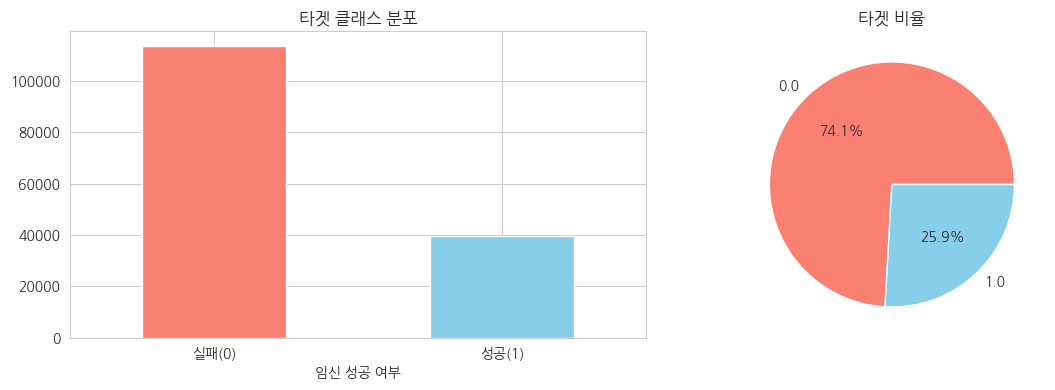

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 클래스 분포
train_copy[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'skyblue'])
axes[0].set_title('타겟 클래스 분포')
axes[0].set_xticklabels(['실패(0)', '성공(1)'], rotation=0)

# 비율
train_copy[TARGET].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
                                                      autopct='%.1f%%', colors=['salmon', 'skyblue'])
axes[1].set_title('타겟 비율')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

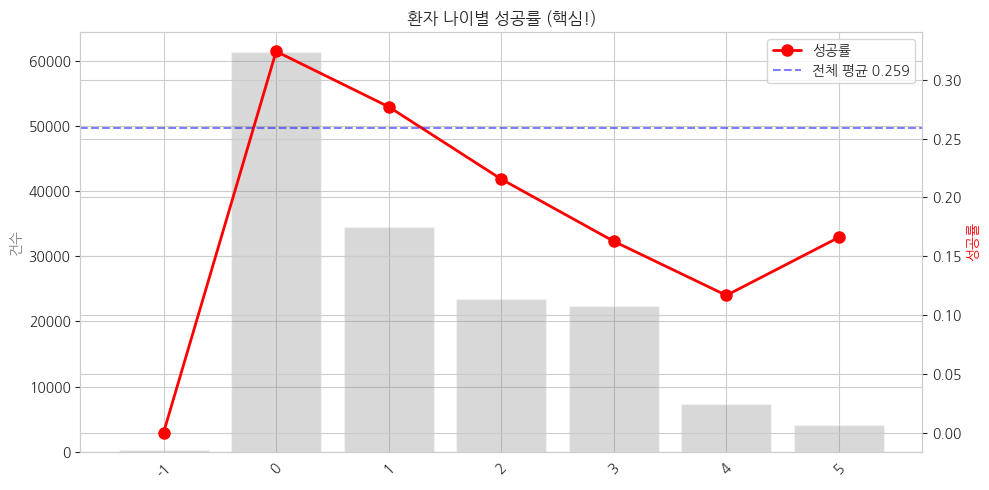

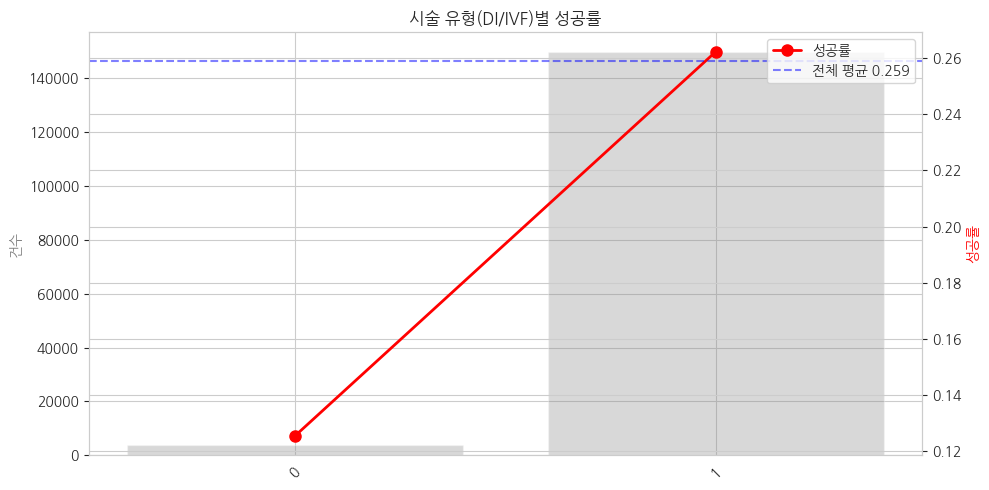

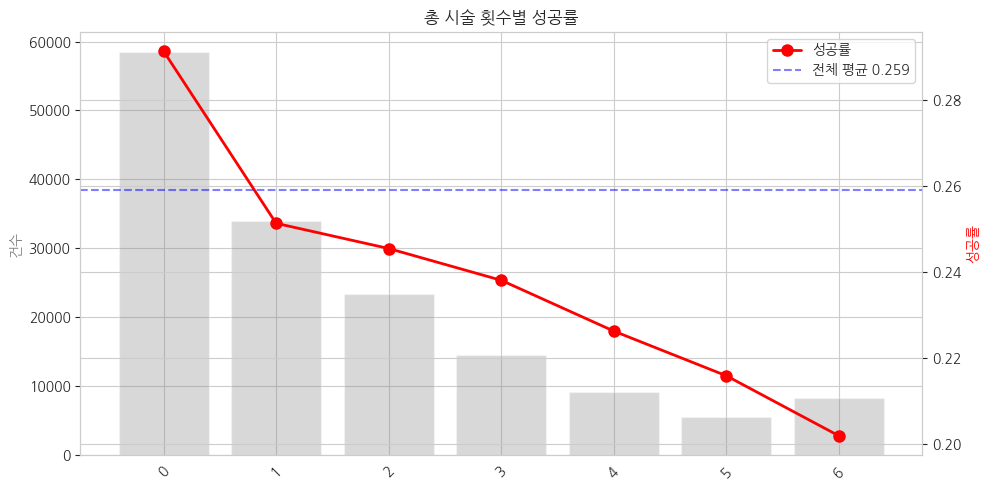

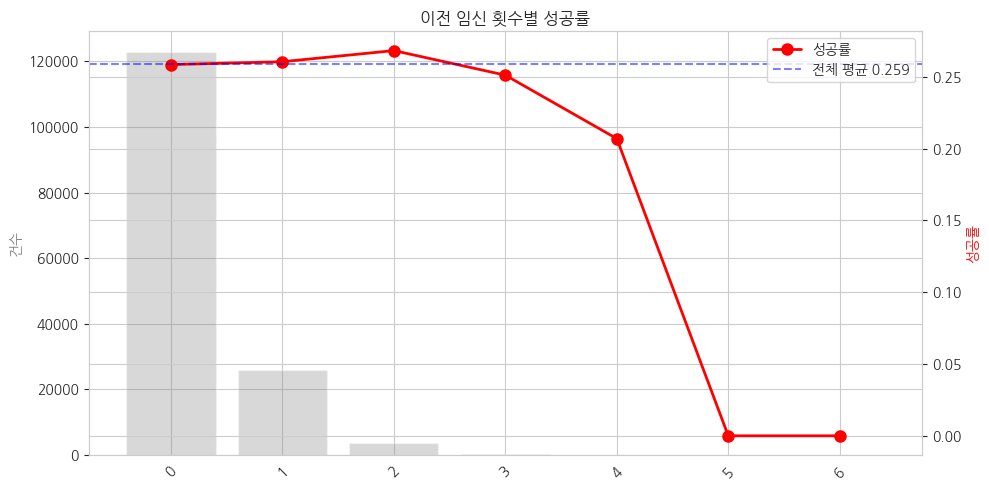

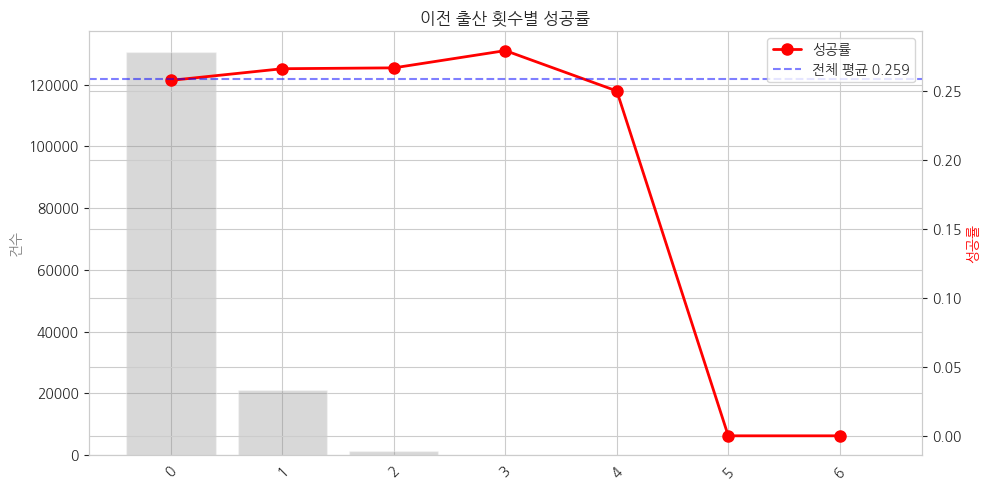

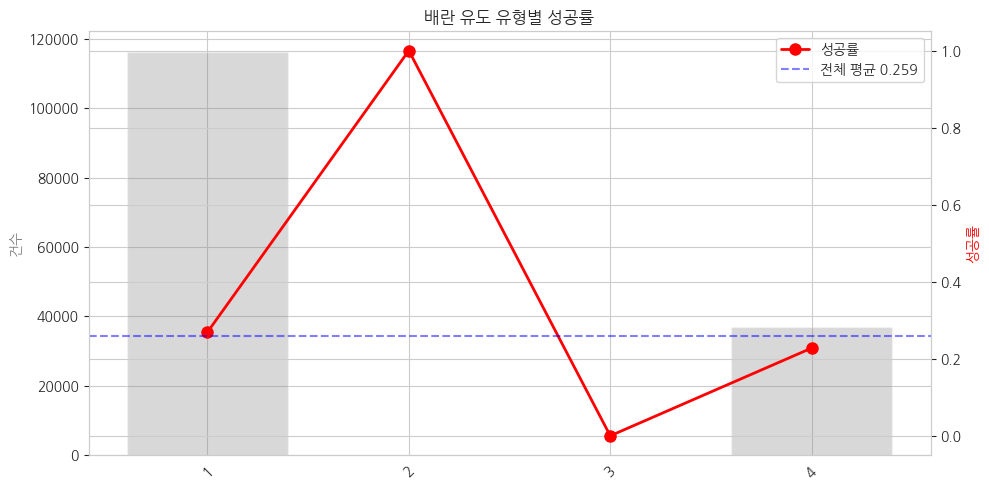

In [21]:
def plot_success_rate(col, title=None, figsize=(10, 5)):
    """카테고리별 성공률을 시각화"""
    grouped = train_copy.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()

    fig, ax1 = plt.subplots(figsize=figsize)

    # 막대: 건수
    ax1.bar(grouped[col].astype(str), grouped['count'], alpha=0.3, color='gray', label='건수')
    ax1.set_ylabel('건수', color='gray')
    ax1.tick_params(axis='x', rotation=45)

    # 선: 성공률
    ax2 = ax1.twinx()
    ax2.plot(grouped[col].astype(str), grouped['mean'], 'o-', color='red', linewidth=2, markersize=8, label='성공률')
    ax2.axhline(BASELINE, color='blue', linestyle='--', alpha=0.5, label=f'전체 평균 {BASELINE:.3f}')
    ax2.set_ylabel('성공률', color='red')
    ax2.legend(loc='upper right')

    plt.title(title or f'{col}별 성공률')
    plt.tight_layout()
    plt.show()

# 핵심 변수들
plot_success_rate('시술 당시 나이', '환자 나이별 성공률 (핵심!)')
plot_success_rate('시술 유형', '시술 유형(DI/IVF)별 성공률')
plot_success_rate('총 시술 횟수', '총 시술 횟수별 성공률')
plot_success_rate('총 임신 횟수', '이전 임신 횟수별 성공률')
plot_success_rate('총 출산 횟수', '이전 출산 횟수별 성공률')
plot_success_rate('배란 유도 유형', '배란 유도 유형별 성공률')

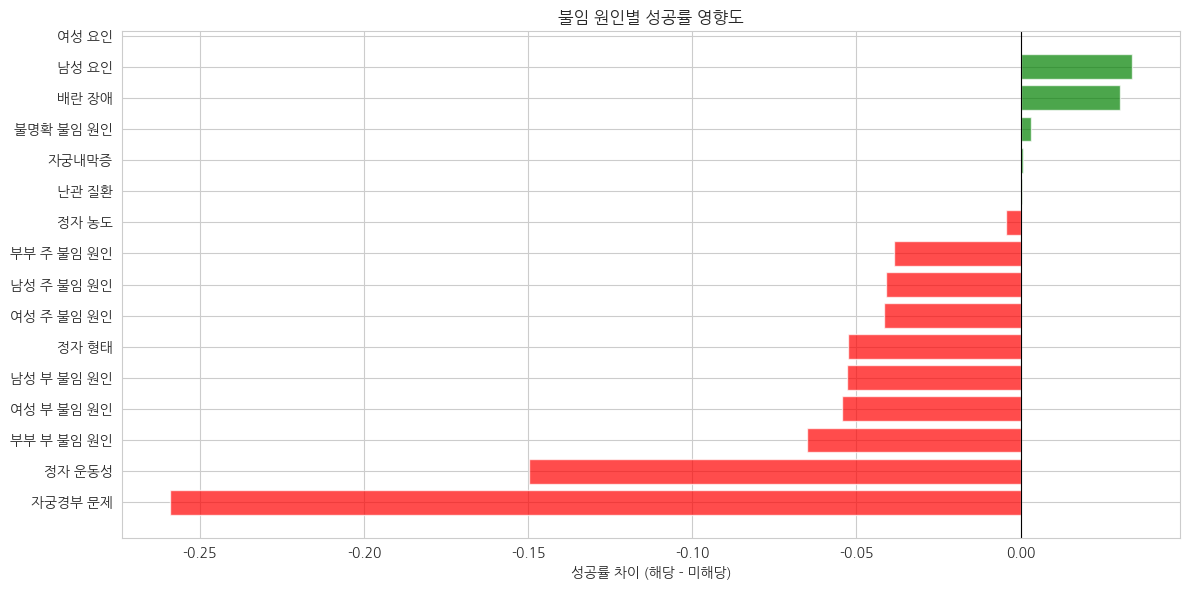

        원인   해당_성공률  미해당_성공률        차이  해당건수
   자궁경부 문제 0.000000 0.258972 -0.258972     5
    정자 운동성 0.109375 0.259026 -0.149651    64
부부 부 불임 원인 0.194611 0.259529 -0.064918  1336
여성 부 불임 원인 0.205182 0.259635 -0.054452  1891
남성 부 불임 원인 0.206897 0.259652 -0.052755  2001
     정자 형태 0.206522 0.258995 -0.052473    92
여성 주 불임 원인 0.218563 0.260234 -0.041671  4676
남성 주 불임 원인 0.219054 0.260118 -0.041064  4314
부부 주 불임 원인 0.221802 0.260220 -0.038419  5018
     정자 농도 0.254658 0.258968 -0.004310   161
     난관 질환 0.259240 0.258919  0.000321 21239
     자궁내막증 0.259714 0.258905  0.000809 10989
 불명확 불임 원인 0.261403 0.258145  0.003258 38519
     배란 장애 0.285257 0.255025  0.030232 19982
     남성 요인 0.280287 0.246373  0.033914 56938
     여성 요인      NaN 0.258963       NaN     0
정자 면역학적 요인      NaN 0.258963       NaN     0


In [22]:
# 불임 원인 이진 컬럼 12개
infertility_cols = [col for col in train_copy.columns if '불임 원인' in col or '부부 주' in col or '부부 부' in col or '남성 주' in col or '남성 부' in col or '여성 주' in col or '여성 부' in col or '불명확' in col]

fig, ax = plt.subplots(figsize=(12, 6))
success_by_cause = []
for col in infertility_cols:
    rate_1 = train_copy.loc[train_copy[col] == 1, TARGET].mean()
    rate_0 = train_copy.loc[train_copy[col] == 0, TARGET].mean()
    count_1 = (train_copy[col] == 1).sum()
    success_by_cause.append({
        '원인': col.replace('불임 원인 - ', ''),
        '해당_성공률': rate_1,
        '미해당_성공률': rate_0,
        '차이': rate_1 - rate_0,
        '해당건수': count_1
    })

cause_df = pd.DataFrame(success_by_cause).sort_values('차이')
colors = ['red' if x < 0 else 'green' for x in cause_df['차이']]
ax.barh(cause_df['원인'], cause_df['차이'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('성공률 차이 (해당 - 미해당)')
ax.set_title('불임 원인별 성공률 영향도')
plt.tight_layout()
plt.show()

print(cause_df.to_string(index=False))

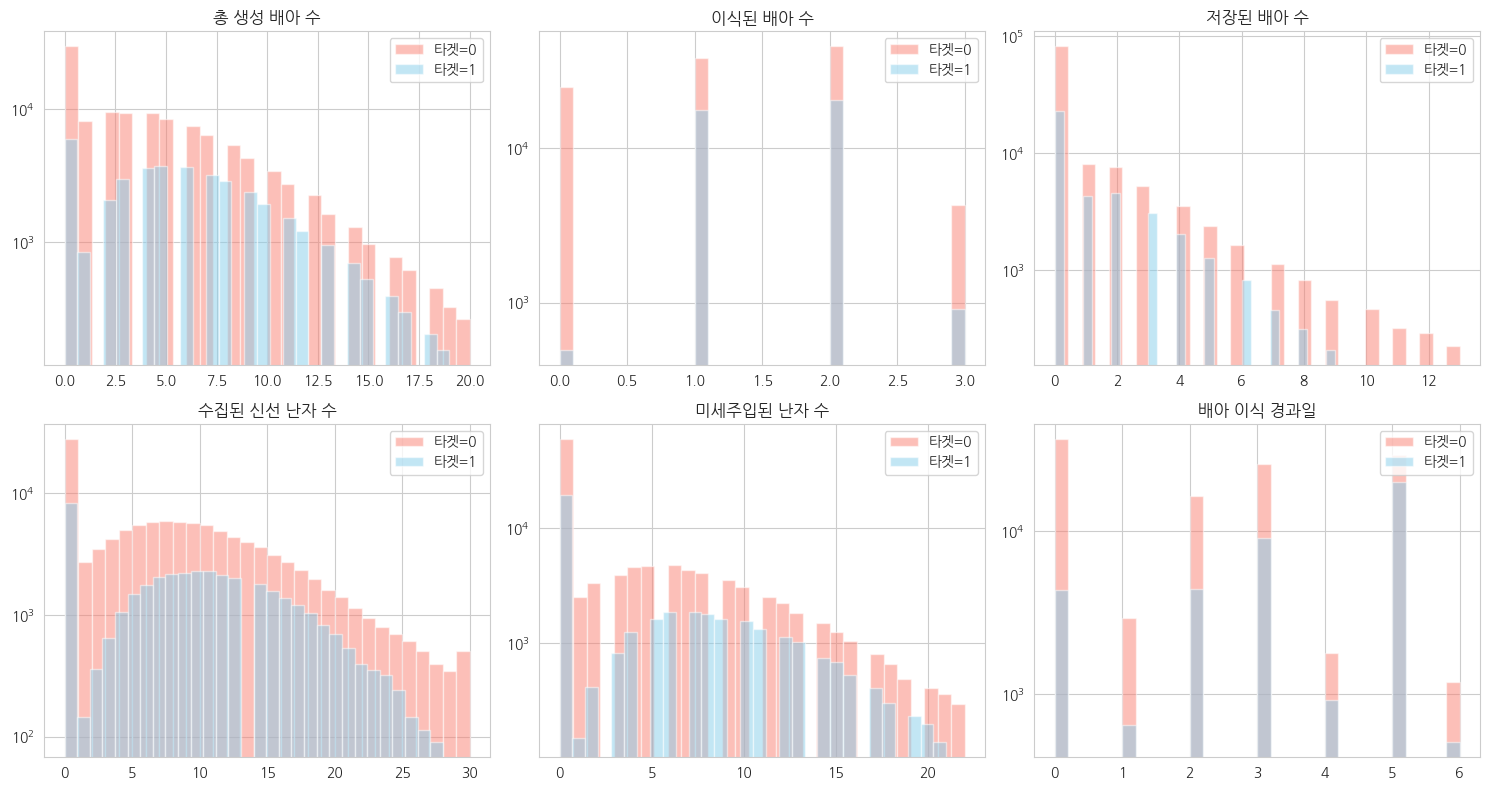

In [23]:
numeric_key_cols = [
    '총 생성 배아 수', '이식된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '미세주입된 난자 수',
    '배아 이식 경과일',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_key_cols):
    ax = axes[i//3, i%3]
    for target_val, color in [(0, 'salmon'), (1, 'skyblue')]:
        data = train_copy.loc[train_copy[TARGET] == target_val, col]
        # 극단값 제거 (상위 1% 이상은 제외)
        upper = data.quantile(0.99)
        data = data[data <= upper]
        ax.hist(data, bins=30, alpha=0.5, label=f'타겟={int(target_val)}', color=color)
    ax.set_title(col)
    ax.legend()
    ax.set_yscale('log')  # 분포가 치우쳐 있으므로 로그 스케일

plt.tight_layout()
plt.show()

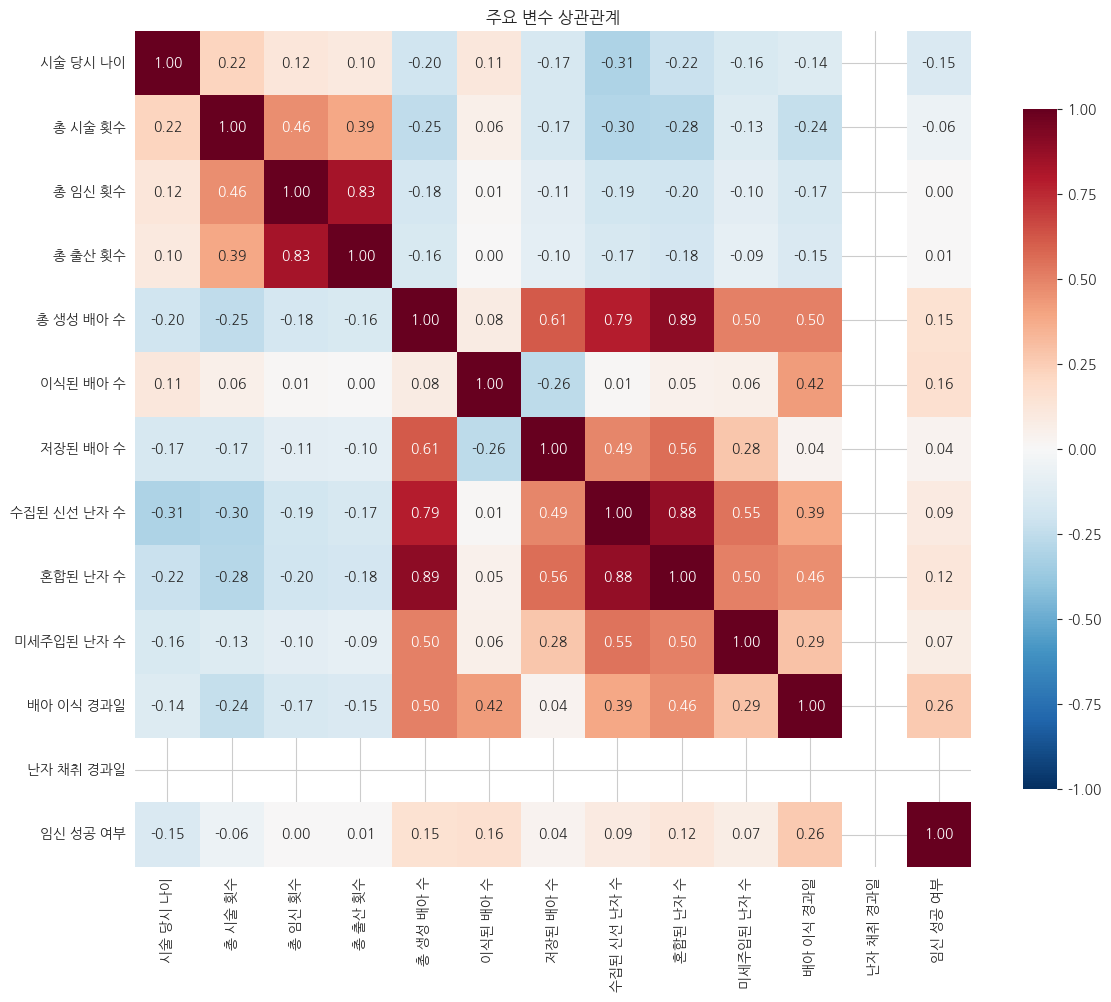

타겟과의 상관계수 절댓값 Top 10:
배아 이식 경과일      0.261574
이식된 배아 수       0.162446
시술 당시 나이       0.149113
총 생성 배아 수      0.149056
혼합된 난자 수       0.119254
수집된 신선 난자 수    0.086613
미세주입된 난자 수     0.071548
총 시술 횟수        0.059667
저장된 배아 수       0.037812
총 출산 횟수        0.006588
Name: 임신 성공 여부, dtype: float64


In [24]:
# 수치형 변수만 선택 (너무 많으면 읽기 어려우므로 주요 변수만)
key_numeric = [
    '시술 당시 나이', '총 시술 횟수', '총 임신 횟수', '총 출산 횟수',
    '총 생성 배아 수', '이식된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '혼합된 난자 수', '미세주입된 난자 수',
    '배아 이식 경과일', '난자 채취 경과일',
    TARGET
]

plt.figure(figsize=(12, 10))
corr = train_copy[key_numeric].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('주요 변수 상관관계')
plt.tight_layout()
plt.show()

# 타겟과의 상관계수 순위
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("타겟과의 상관계수 절댓값 Top 10:")
print(target_corr.head(10))

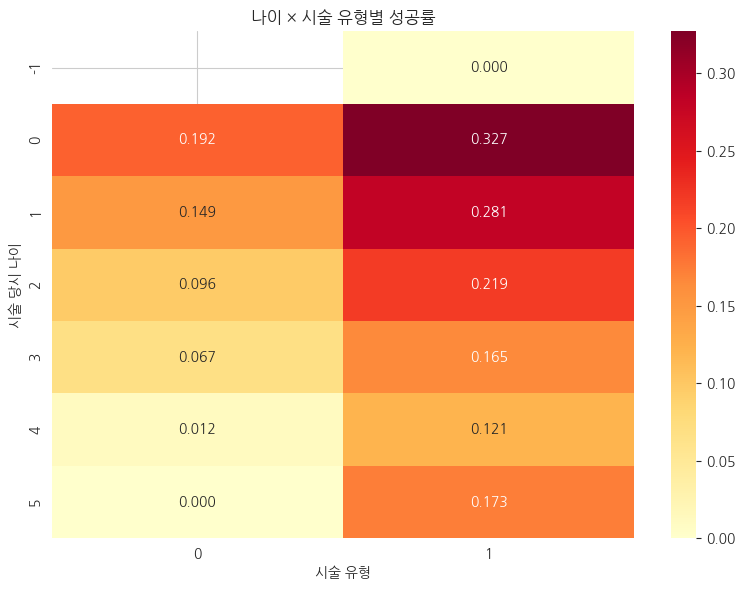

In [25]:
# 피벗 테이블: 나이 × 시술 유형별 성공률
pivot = train_copy.pivot_table(
    index='시술 당시 나이',
    columns='시술 유형',
    values=TARGET,
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('나이 × 시술 유형별 성공률')
plt.tight_layout()
plt.show()

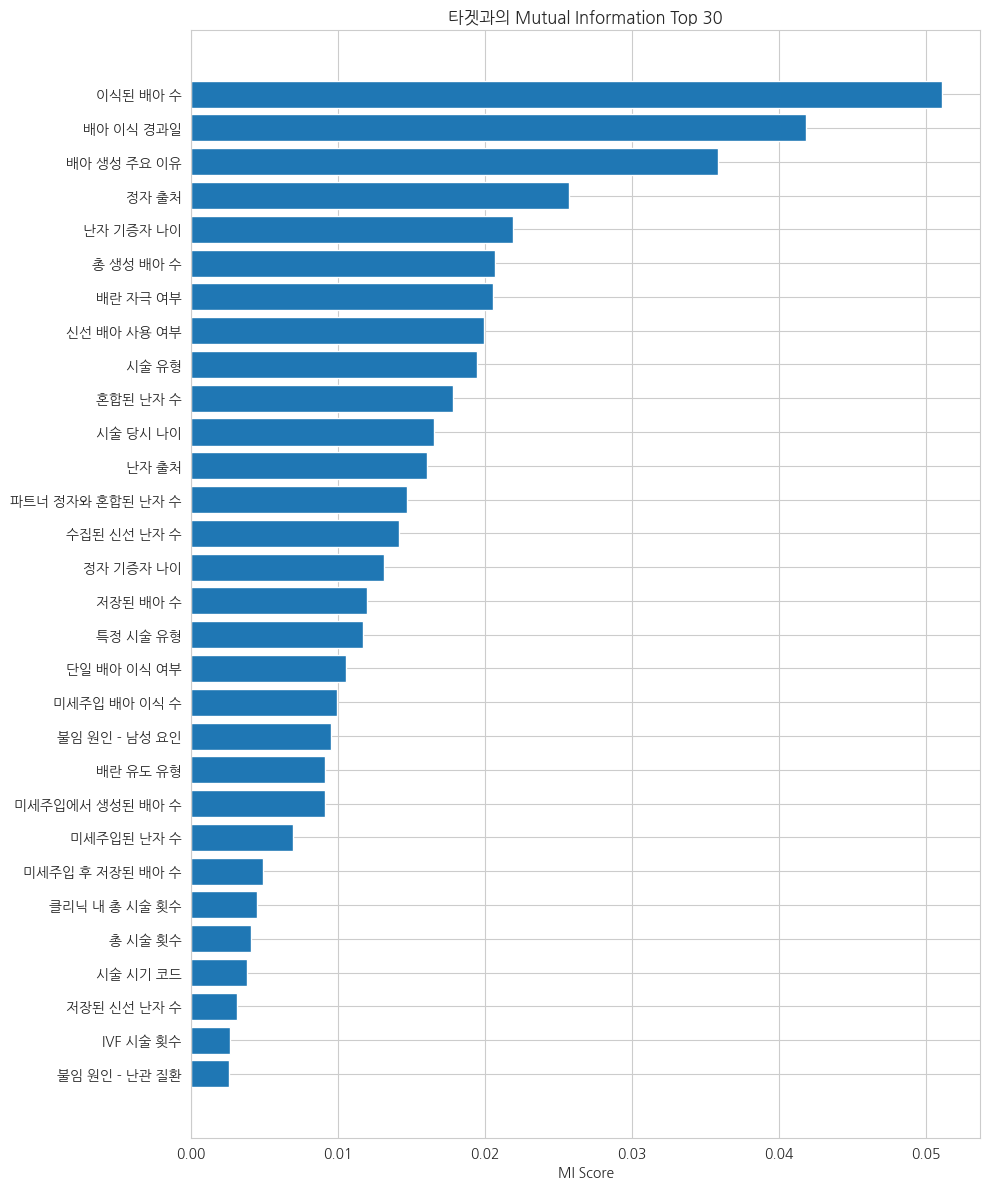

             feature  mi_score
40          이식된 배아 수  0.051140
64         배아 이식 경과일  0.041868
26       배아 생성 주요 이유  0.035893
52             정자 출처  0.025742
53         난자 기증자 나이  0.021937
37         총 생성 배아 수  0.020657
4           배란 자극 여부  0.020575
56       신선 배아 사용 여부  0.019946
2              시술 유형  0.019458
48          혼합된 난자 수  0.017816
1           시술 당시 나이  0.016515
51             난자 출처  0.016072
49  파트너 정자와 혼합된 난자 수  0.014721
46       수집된 신선 난자 수  0.014116
54         정자 기증자 나이  0.013109
42          저장된 배아 수  0.011971
3           특정 시술 유형  0.011691
6        단일 배아 이식 여부  0.010538
41      미세주입 배아 이식 수  0.009947
17     불임 원인 - 남성 요인  0.009536


In [26]:
from sklearn.feature_selection import mutual_info_classif

X = train_copy.drop(columns=['ID', TARGET])
y = train_copy[TARGET].astype(int)

# MI 계산 (시간 좀 걸림)
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(mi_df['feature'][:30][::-1], mi_df['mi_score'][:30][::-1])
plt.title('타겟과의 Mutual Information Top 30')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

print(mi_df.head(20))